# Artificial Neural Networks and Deep Learning
---
## Time-Series Classification — UCI HAR Dataset

Multiclass time-series classification: predict the human activity
(walking, sitting, standing, etc.) from smartphone accelerometer and gyroscope data,
using a bidirectional LSTM with learned attention.

**Pipeline:**
1. Data loading & encoding
2. Exploratory data analysis
3. Windowing + augmentation utilities
4. Model definition
5. Training / validation loops
6. Hyperparameter tuning — Grid Search
7. Final K-Fold cross-validation with best config
8. Weighted ensemble inference

## 1 · Google Drive Connection

In [9]:
from google.colab import drive
drive.mount("/gdrive")
current_dir = "/gdrive/MyDrive/AN2DL Challenges/HAR"
%cd $current_dir

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
/gdrive/MyDrive/AN2DL Challenges/HAR


## 2 · Libraries & Reproducibility

In [10]:
SEED = 42

import os, random, warnings, copy, glob
from itertools import product

os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR']   = os.getcwd() + '/configs/'
warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', Warning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(SEED)
random.seed(SEED)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

os.makedirs("models", exist_ok=True)
os.makedirs("configs", exist_ok=True)

sns.set(font_scale=1.3)
sns.set_style('white')
%matplotlib inline

print(f"PyTorch {torch.__version__} | Device: {device}")

PyTorch 2.10.0+cpu | Device: cpu


## 3 · Data Loading & Encoding

In [29]:
DATA_ROOT = "UCI HAR Dataset"

def load_har_split(split):
    X = pd.read_csv(f"{DATA_ROOT}/X_{split}.txt",
                    sep=r'\s+', header=None)
    y = pd.read_csv(f"{DATA_ROOT}/y_{split}.txt",
                    sep=r'\s+', header=None, names=['label'])
    subj = pd.read_csv(f"{DATA_ROOT}/subject_{split}.txt",
                       sep=r'\s+', header=None, names=['subject'])

    # Ogni riga è già una finestra di 128 timestep
    # Trattiamo ogni riga come un sample indipendente
    n = len(X)
    df = pd.concat([pd.Series(range(n), name='sample_index'),
                    pd.Series(np.zeros(n, dtype=int), name='timestamp'),
                    X], axis=1)
    df.columns = ['sample_index', 'timestamp'] + [f'f{i}' for i in range(X.shape[1])]
    df = df.astype({c: np.float32 for c in df.columns[2:]})

    labels = pd.DataFrame({
        'sample_index': range(n),
        'label': y['label'].values
    })
    return df, labels

X_train_raw, y_train_raw = load_har_split('train')
X_test_raw,  y_test_raw  = load_har_split('test')

print(f"Train : {X_train_raw.shape}")
print(f"Labels: {y_train_raw.shape}")
print(f"Test  : {X_test_raw.shape}")
X_train_raw.head(3)

Train : (7352, 563)
Labels: (7352, 2)
Test  : (2947, 563)


,sample_index,timestamp,f0,f1,f2,f3,f4,f5,f6,f7,...,f551,f552,f553,f554,f555,f556,f557,f558,f559,f560
0,0,0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,1,0,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,2,0,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118


In [30]:
# Activity labels (1-indexed in HAR)
ACTIVITY_NAMES = {
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING'
}

# Remap 1-indexed labels to 0-indexed
pain_code = {v: k-1 for k, v in ACTIVITY_NAMES.items()}
inv_pain  = {v: k   for k, v in pain_code.items()}

X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()
y_train = y_train_raw.copy()
y_test  = y_test_raw.copy()

y_train['label'] = y_train['label'] - 1
y_test['label']  = y_test['label']  - 1

num_classes = len(ACTIVITY_NAMES)
IN_FEATURES = X_train.shape[1] - 2
print(f"Classes ({num_classes}): {ACTIVITY_NAMES}")
print(f"Input features per timestep: {IN_FEATURES}")

Classes (6): {1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS', 4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}
Input features per timestep: 561


## 4 · Exploratory Data Analysis

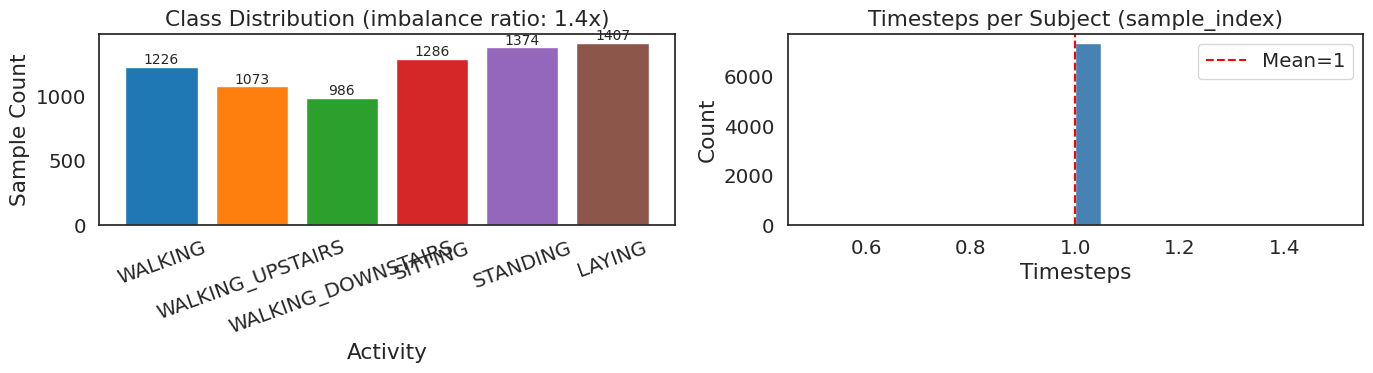

Samples per class:
  WALKING                  : 1226  (16.7%)
  WALKING_UPSTAIRS         : 1073  (14.6%)
  WALKING_DOWNSTAIRS       :  986  (13.4%)
  SITTING                  : 1286  (17.5%)
  STANDING                 : 1374  (18.7%)
  LAYING                   : 1407  (19.1%)

Timesteps — min:1  max:1  mean:1.0


In [31]:
# Class distribution + sample lengths
label_counts = y_train['label'].value_counts().sort_index()
label_names  = [ACTIVITY_NAMES[i+1] for i in label_counts.index]
lengths      = X_train.groupby('sample_index').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(label_names, label_counts.values,
            color=sns.color_palette('tab10', num_classes), edgecolor='white')
imbalance = label_counts.max() / label_counts.min()
axes[0].set_title(f'Class Distribution (imbalance ratio: {imbalance:.1f}x)')
axes[0].set_xlabel('Activity'); axes[0].set_ylabel('Sample Count')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(axes[0].patches, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontsize=10)

axes[1].hist(lengths, bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Timesteps per Subject (sample_index)')
axes[1].set_xlabel('Timesteps'); axes[1].set_ylabel('Count')
axes[1].axvline(lengths.mean(), color='red', linestyle='--',
                label=f'Mean={lengths.mean():.0f}')
axes[1].legend()

plt.tight_layout(); plt.show()

print("Samples per class:")
for i, c in label_counts.items():
    print(f"  {ACTIVITY_NAMES[i+1]:25s}: {c:4d}  ({c/len(y_train)*100:.1f}%)")
print(f"\nTimesteps — min:{lengths.min()}  max:{lengths.max()}  mean:{lengths.mean():.1f}")

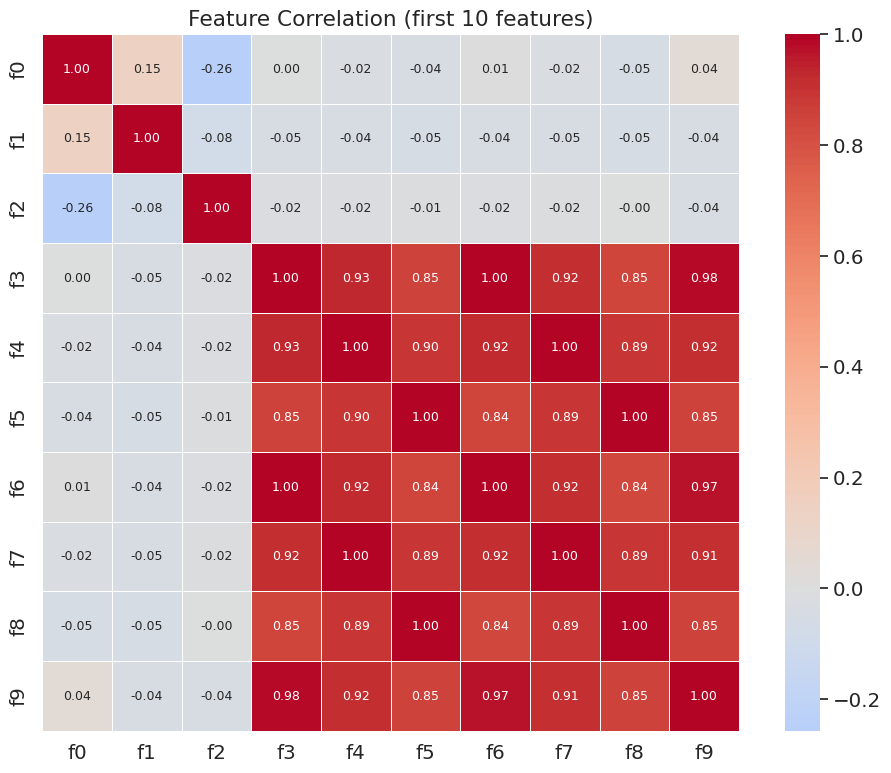

In [32]:
# Feature correlation heatmap (first 10 features)
joint_cols = X_train.columns[2:12]
corr = X_train[joint_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation (first 10 features)')
plt.tight_layout(); plt.show()

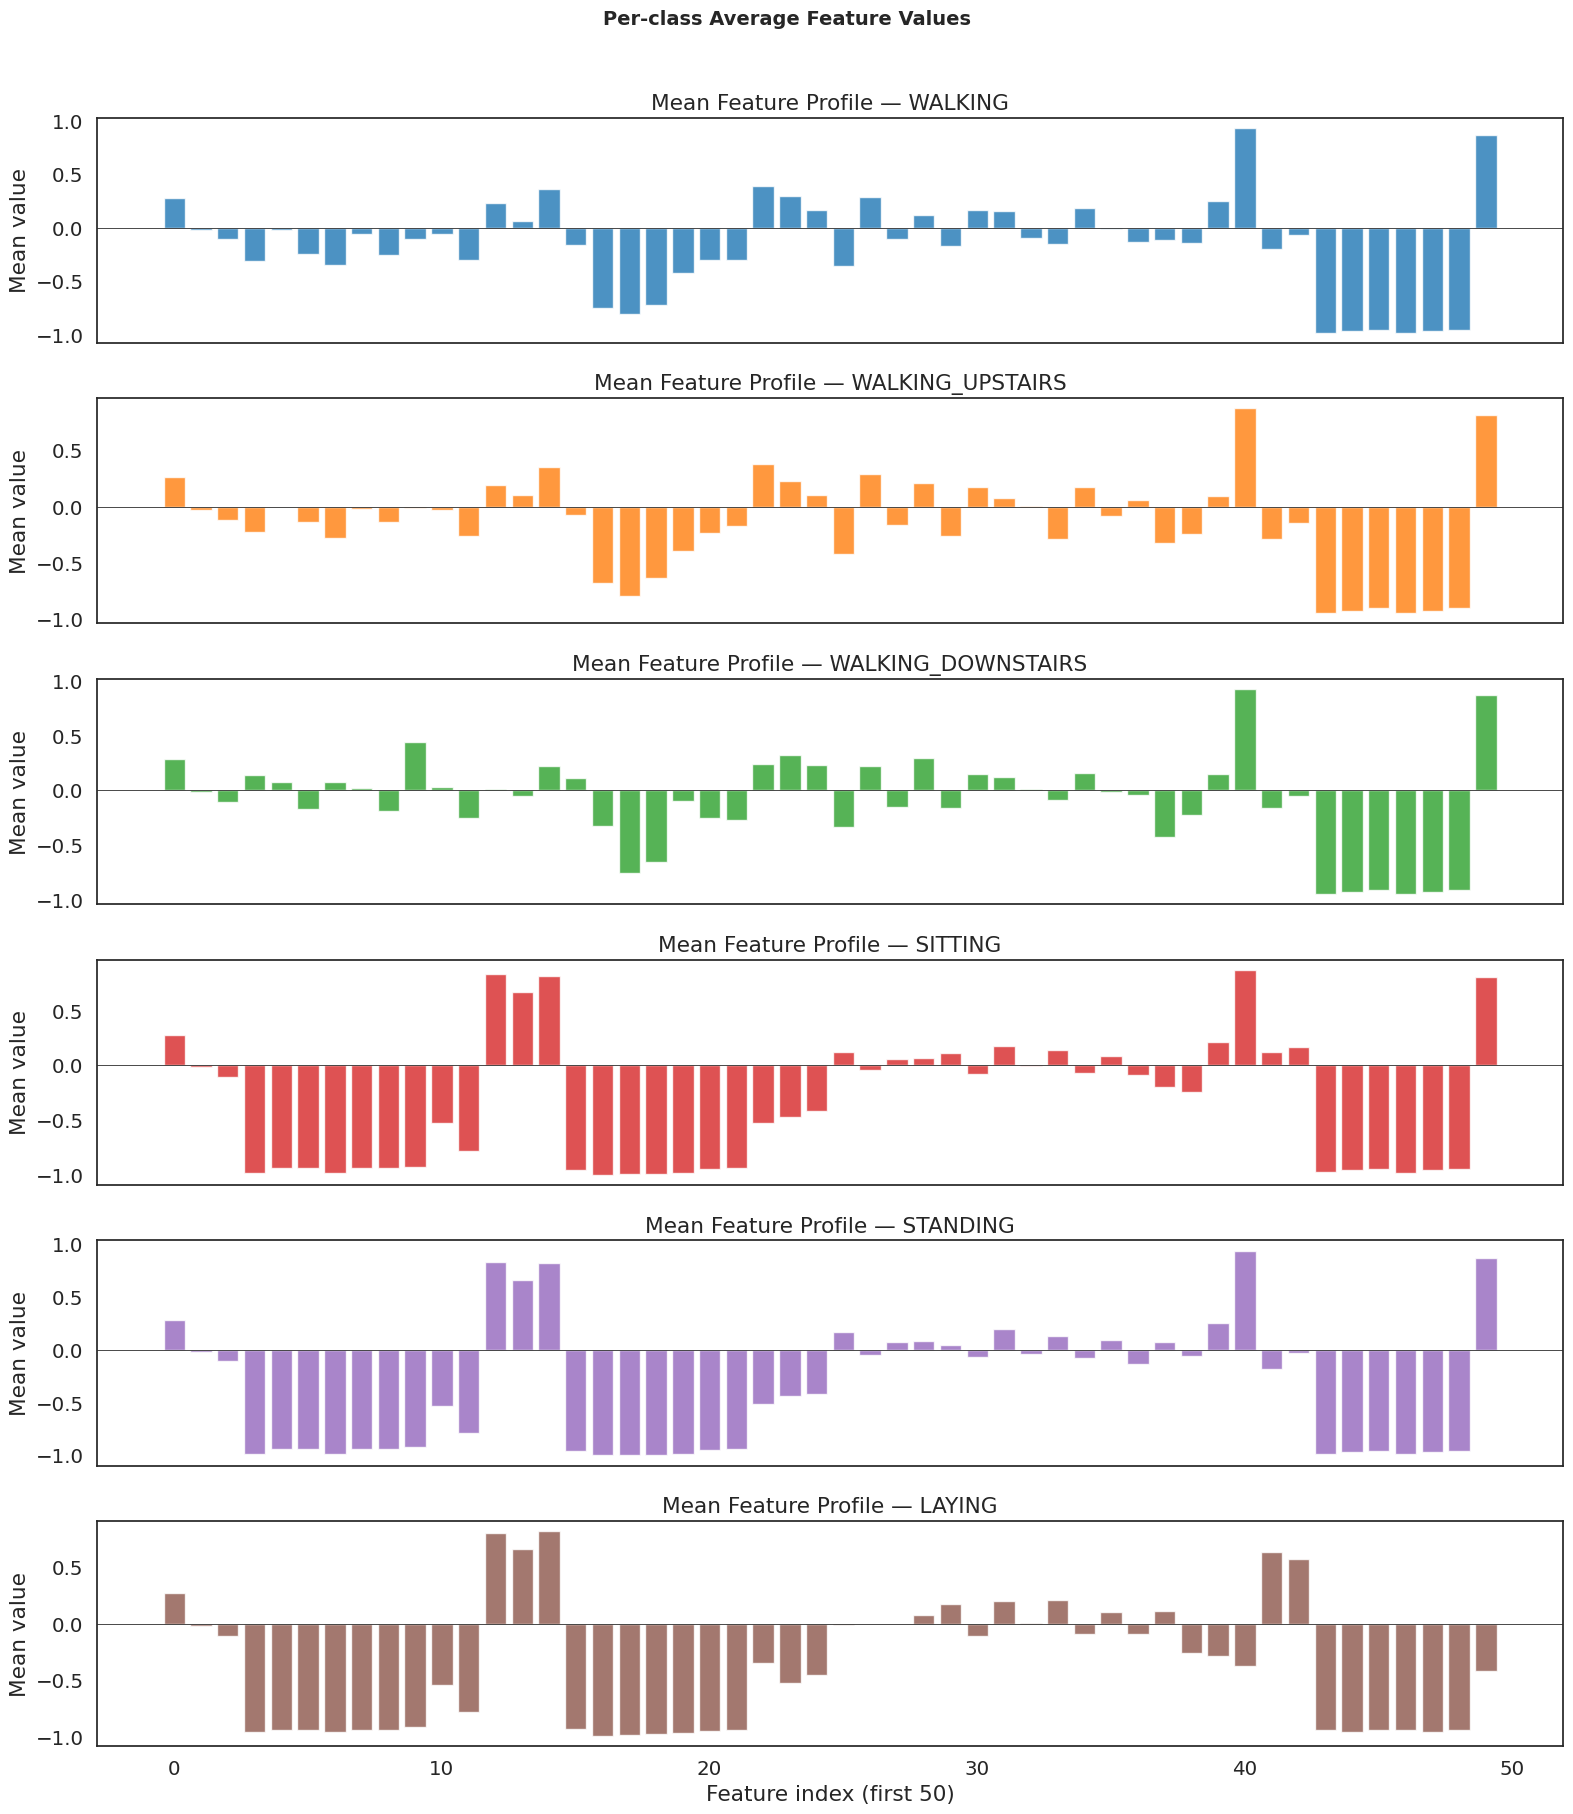

In [33]:
# Per-class mean feature profiles (first 50 features for readability)
feat_cols = X_train.columns[2:52]
merged    = X_train.merge(y_train, on='sample_index')

fig, axes = plt.subplots(num_classes, 1, figsize=(16, 3 * num_classes), sharex=True)

for cls_idx, ax in enumerate(axes):
    cls_data = merged[merged['label'] == cls_idx][feat_cols].mean()
    ax.bar(range(len(cls_data)), cls_data.values,
           color=sns.color_palette('tab10', num_classes)[cls_idx], alpha=0.8)
    ax.set_title(f'Mean Feature Profile — {ACTIVITY_NAMES[cls_idx+1]}')
    ax.set_ylabel('Mean value')
    ax.axhline(0, color='black', linewidth=0.5)

axes[-1].set_xlabel('Feature index (first 50)')
plt.suptitle('Per-class Average Feature Values', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

In [34]:
# Window-count simulation for candidate window/stride values
print(f"{'window':>8} {'stride':>8} {'sequences':>12} {'coverage':>12}")
print("─" * 44)
for ws, st in [(32,32), (64,64), (128,128), (128,64), (64,32)]:
    n_seq = sum(((l + (ws - l % ws if l % ws else 0)) // st) for l in lengths)
    print(f"{ws:>8} {st:>8} {n_seq:>12,} {ws/lengths.mean()*100:>11.0f}%")

  window   stride    sequences     coverage
────────────────────────────────────────────
      32       32        7,352        3200%
      64       64        7,352        6400%
     128      128        7,352       12800%
     128       64       14,704       12800%
      64       32       14,704        6400%


## 5 · Data Pipeline Utilities

In [35]:
def build_sequence(df, target_df=None, window=128, stride=128):
    """
    Sliding-window segmentation with NumPy stride tricks (zero-copy).
    Pads the last incomplete window with zeros.
    """
    feature_cols = df.columns[2:]
    X_list, y_list = [], []

    for sid in df['sample_index'].unique():
        temp = df.loc[df['sample_index'] == sid, feature_cols].values.astype(np.float32)
        remainder = len(temp) % stride
        if remainder:
            pad  = np.zeros((stride - remainder, temp.shape[1]), dtype=np.float32)
            temp = np.concatenate([temp, pad], axis=0)

        T, F    = temp.shape
        n_win   = max(1, (T - window) // stride + 1)
        shape   = (n_win, window, F)
        strides = (stride * temp.strides[0], temp.strides[0], temp.strides[1])
        wins    = np.lib.stride_tricks.as_strided(temp, shape=shape, strides=strides).copy()
        X_list.append(wins)

        if target_df is not None:
            lbl = target_df.loc[target_df['sample_index'] == sid, 'label'].values[0]
            y_list.extend([lbl] * n_win)

    X = np.concatenate(X_list, axis=0)
    if target_df is not None:
        return X, np.array(y_list, dtype=np.int64)
    return X


def augment_sequences(X, y, noise_std=0.02, time_mask_frac=0.15,
                      feat_mask_frac=0.10, seed=42):
    """
    Training-only augmentation: 4x sequences via noise, time masking, feature masking.
    Never apply to validation or test.
    """
    rng = np.random.default_rng(seed)
    N, T, F = X.shape
    X_parts, y_parts = [X], [y]

    X_parts.append((X + rng.normal(0, noise_std, X.shape)).astype(np.float32))
    y_parts.append(y)

    Xt   = X.copy()
    mlen = max(1, int(T * time_mask_frac))
    for i, s in enumerate(rng.integers(0, T - mlen, size=N)):
        Xt[i, s:s + mlen, :] = 0.0
    X_parts.append(Xt); y_parts.append(y)

    Xf = X.copy()
    nf = max(1, int(F * feat_mask_frac))
    for i in range(N):
        Xf[i, :, rng.integers(0, F, size=nf)] = 0.0
    X_parts.append(Xf); y_parts.append(y)

    X_aug = np.concatenate(X_parts, axis=0)
    y_aug = np.concatenate(y_parts, axis=0)
    perm  = rng.permutation(len(X_aug))
    return X_aug[perm], y_aug[perm]


def make_loader(ds, batch_size, shuffle=False, sampler=None):
    """DataLoader compatible with Colab (num_workers=0)."""
    return DataLoader(
        ds, batch_size=batch_size,
        shuffle=(shuffle and sampler is None),
        sampler=sampler,
        num_workers=0,
        pin_memory=(device.type == 'cuda'),
    )

## 6 · Model Architecture

In [36]:
class RecurrentClassifier(nn.Module):
    """
    Bidirectional RNN (LSTM / GRU / RNN) with:
      - LayerNorm after the recurrent stack
      - Learned single-head attention pooling over time
      - Projection MLP with dropout before the classifier head
    """
    def __init__(self, input_size, hidden_size, num_layers, num_classes,
                 rnn_type='LSTM', bidirectional=True, dropout_rate=0.3):
        super().__init__()
        rnn_cls = {'LSTM': nn.LSTM, 'GRU': nn.GRU, 'RNN': nn.RNN}
        if rnn_type not in rnn_cls:
            raise ValueError(f"rnn_type must be one of {list(rnn_cls)}")
        self.rnn = rnn_cls[rnn_type](
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout_rate if num_layers > 1 else 0.0,
        )
        D = hidden_size * (2 if bidirectional else 1)
        self.norm = nn.LayerNorm(D)
        self.attn = nn.Linear(D, 1, bias=False)
        proj_dim  = max(hidden_size // 2, num_classes * 2)
        self.proj = nn.Sequential(nn.Linear(D, proj_dim), nn.GELU(), nn.Dropout(dropout_rate))
        self.drop = nn.Dropout(dropout_rate)
        self.fc   = nn.Linear(proj_dim, num_classes)

    def forward(self, x):
        out, _  = self.rnn(x)
        out     = self.norm(out)
        weights = torch.softmax(self.attn(out), dim=1)
        ctx     = (out * weights).sum(dim=1)
        return self.fc(self.proj(self.drop(ctx)))


class FocalLoss(nn.Module):
    """Focal Loss with per-class weights and label smoothing. Accepts raw logits."""
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma; self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, reduction='none',
                               label_smoothing=self.label_smoothing)
        pt   = torch.exp(-F.cross_entropy(logits, targets, reduction='none'))
        loss = (1 - pt) ** self.gamma * ce
        if self.alpha is not None:
            loss = self.alpha.type_as(logits).gather(0, targets) * loss
        return loss.mean()


def build_model(config, in_features, n_classes, device):
    return RecurrentClassifier(
        input_size   = in_features,
        hidden_size  = config['hidden_size'],
        num_layers   = config['hidden_layers'],
        num_classes  = n_classes,
        rnn_type     = config.get('rnn_type', 'LSTM'),
        bidirectional= config.get('bidirectional', True),
        dropout_rate = config['dropout_rate'],
    ).to(device)

## 7 · Training & Validation Loops

In [37]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device, l1_lambda=0.0):
    model.train()
    total_loss, preds, targets = 0.0, [], []
    for X, y in loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(X)
            loss   = criterion(logits, y)
        if l1_lambda > 0:
            loss = loss + l1_lambda * sum(p.abs().sum() for p in model.parameters() if p.requires_grad)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item() * X.size(0)
        preds.append(logits.argmax(1).cpu().numpy())
        targets.append(y.cpu().numpy())
    return (total_loss / len(loader.dataset),
            f1_score(np.concatenate(targets), np.concatenate(preds), average='weighted'))


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, preds, targets = 0.0, [], []
    for X, y in loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(X); loss = criterion(logits, y)
        total_loss += loss.item() * X.size(0)
        preds.append(logits.argmax(1).cpu().numpy())
        targets.append(y.cpu().numpy())
    return (total_loss / len(loader.dataset),
            f1_score(np.concatenate(targets), np.concatenate(preds), average='weighted'))


def fit(model, tr_loader, vl_loader, epochs, criterion, optimizer,
        scaler, device, l1_lambda=0.0, patience=20,
        scheduler=None, verbose=0, experiment_name="model"):
    """Training loop with early stopping on val F1 and best-weight checkpointing."""
    history = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[]}
    best_f1, best_ep, no_imp = -np.inf, 0, 0
    ckpt = f"models/{experiment_name}_model.pt"
    os.makedirs(os.path.dirname(ckpt), exist_ok=True)

    for ep in range(1, epochs + 1):
        tr_l, tr_f = train_one_epoch(model, tr_loader, criterion, optimizer, scaler, device, l1_lambda)
        vl_l, vl_f = validate_one_epoch(model, vl_loader, criterion, device)

        if scheduler is not None:
            scheduler.step(ep - 1 + 1 / len(tr_loader))

        history['train_loss'].append(tr_l); history['val_loss'].append(vl_l)
        history['train_f1'].append(tr_f);   history['val_f1'].append(vl_f)

        if verbose > 0 and (ep % verbose == 0 or ep == 1):
            lr = optimizer.param_groups[0]['lr']
            print(f"  Ep {ep:3d}/{epochs} | "
                  f"Train L={tr_l:.4f} F1={tr_f:.4f} | "
                  f"Val   L={vl_l:.4f} F1={vl_f:.4f} | LR={lr:.2e}")

        if vl_f > best_f1:
            best_f1, best_ep, no_imp = vl_f, ep, 0
            torch.save(model.state_dict(), ckpt)
        else:
            no_imp += 1
            if patience > 0 and no_imp >= patience:
                if verbose > 0:
                    print(f"  Early stop ep {ep}  (best F1={best_f1:.4f} @ ep {best_ep})")
                break

    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=device))
    return model, history

## 8 · K-Fold Cross-Validation Engine

In [38]:
def run_cv(X_train, y_train, config, cv_config, experiment_name="exp"):
    """
    K-Fold CV with disjoint sample-level splits.
    k=1: single 70/30 split (fast, for grid search).
    k>1: true K-Fold, each sample in val exactly once.
    """
    k         = cv_config['k']
    seed      = cv_config.get('seed', 42)
    criterion = cv_config['criterion']
    dev       = cv_config['device']
    epochs    = cv_config['epochs']
    patience  = cv_config.get('patience', 20)
    verbose   = cv_config.get('verbose', 0)
    class_wts = cv_config.get('class_weights', None)

    ws, stride = config['window_size'], config['stride']
    bs, lr     = config['batch_size'], config['learning_rate']
    l1, l2     = config.get('l1_lambda', 0.0), config.get('l2_lambda', 1e-3)

    n_classes  = y_train['label'].nunique()
    model      = build_model(config, IN_FEATURES, n_classes, dev)
    init_state = copy.deepcopy(model.state_dict())

    samples = X_train['sample_index'].unique().copy()
    np.random.default_rng(seed).shuffle(samples)

    if k == 1:
        n_val  = max(1, round(0.3 * len(samples)))
        splits = [(samples[:-n_val], samples[-n_val:])]
    else:
        groups = np.array_split(samples, k)
        splits = [
            (np.concatenate([groups[j] for j in range(k) if j != i]), groups[i])
            for i in range(k)
        ]

    fold_metrics, fold_losses, best_scores = {}, {}, {}
    os.makedirs(f"models/{experiment_name}", exist_ok=True)

    for fold, (tr_idx, vl_idx) in enumerate(splits):
        db_tr = X_train[X_train['sample_index'].isin(tr_idx)].copy()
        lb_tr = y_train[y_train['sample_index'].isin(tr_idx)].copy()
        db_vl = X_train[X_train['sample_index'].isin(vl_idx)].copy()
        lb_vl = y_train[y_train['sample_index'].isin(vl_idx)].copy()

        feat_cols = db_tr.columns[2:]
        tr_vals   = db_tr[feat_cols].values
        mu, sigma = tr_vals.mean(0), tr_vals.std(0)
        db_tr[feat_cols] = (tr_vals                 - mu) / (sigma + 1e-7)
        db_vl[feat_cols] = (db_vl[feat_cols].values - mu) / (sigma + 1e-7)

        if db_tr.isnull().any().any() or db_vl.isnull().any().any():
            print(f"  [fold {fold+1}] WARNING: NaN after normalisation")

        X_tr, y_tr = build_sequence(db_tr, lb_tr, window=ws, stride=stride)
        X_vl, y_vl = build_sequence(db_vl, lb_vl, window=ws, stride=stride)
        X_tr, y_tr = augment_sequences(X_tr, y_tr, seed=seed + fold)

        if verbose > 0:
            print(f"\n  Fold {fold+1}/{k} | Train: {X_tr.shape} | Val: {X_vl.shape}")

        tr_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
        vl_ds = TensorDataset(torch.from_numpy(X_vl), torch.from_numpy(y_vl))

        if class_wts is not None:
            sw        = [class_wts[lbl] for lbl in y_tr]
            sampler   = WeightedRandomSampler(sw, num_samples=len(sw), replacement=True)
            tr_loader = make_loader(tr_ds, bs, sampler=sampler)
        else:
            tr_loader = make_loader(tr_ds, bs, shuffle=True)
        vl_loader = make_loader(vl_ds, bs)

        model.load_state_dict(init_state)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=l2)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=50, eta_min=1e-5)
        scaler = torch.amp.GradScaler(enabled=(dev.type == 'cuda'))

        model, hist = fit(
            model, tr_loader, vl_loader, epochs, criterion,
            optimizer, scaler, dev,
            l1_lambda=l1, patience=patience, scheduler=scheduler,
            verbose=verbose,
            experiment_name=f"{experiment_name}/fold_{fold}",
        )

        fold_losses[f"split_{fold}"]  = hist['val_loss']
        fold_metrics[f"split_{fold}"] = hist['val_f1']
        best_scores[f"split_{fold}"]  = max(hist['val_f1']) if hist['val_f1'] else 0.0

    vals = [best_scores[f"split_{i}"] for i in range(len(splits))]
    best_scores['mean'] = float(np.mean(vals))
    best_scores['std']  = float(np.std(vals))

    if verbose > 0:
        print(f"\n  CV → {best_scores['mean']:.4f} ± {best_scores['std']:.4f}")

    return fold_metrics, fold_losses, best_scores

## 9 · Hyperparameter Tuning — Grid Search

Each config runs with k=1 (single 70/30 split) and few epochs to quickly rank candidates.
The winner is then retrained with full 5-fold CV.

In [39]:
def grid_search(X_train, y_train, param_grid, base_config, cv_config, top_n=5):
    """
    Exhaustive grid search using run_cv.
    Fast by design: k=1 and short epochs in cv_config.
    """
    keys   = list(param_grid.keys())
    combos = list(product(*param_grid.values()))
    total  = len(combos)
    print(f"Grid search: {total} configs × {cv_config['k']} fold(s) "
          f"| max {cv_config['epochs']} epochs each\n")

    results, best_score, best_config = {}, -np.inf, None

    for idx, combo in enumerate(combos, 1):
        cfg = {**base_config, **dict(zip(keys, combo))}
        tag = " | ".join(f"{k}={v}" for k, v in zip(keys, combo))
        print(f"[{idx:2d}/{total}] {tag}", end="  ")

        _, _, scores = run_cv(X_train, y_train, cfg, cv_config,
                              experiment_name=f"gs/cfg_{idx}")
        results[tag] = scores

        marker = " ★ NEW BEST" if scores['mean'] > best_score else ""
        print(f"F1={scores['mean']:.4f} ± {scores['std']:.4f}{marker}")

        if scores['mean'] > best_score:
            best_score, best_config = scores['mean'], cfg.copy()

    ranked = sorted(results.items(), key=lambda x: x[1]['mean'], reverse=True)
    print(f"\nTop {min(top_n, len(ranked))} configurations:")
    for i, (tag, sc) in enumerate(ranked[:top_n], 1):
        print(f"  {i}. F1={sc['mean']:.4f} ± {sc['std']:.4f}  [{tag}]")
    return results, best_config, best_score


def plot_grid_search_results(results, k, top_n=5):
    """Boxplot of val F1 across folds for the top N configurations."""
    ranked = sorted(results.items(), key=lambda x: x[1]['mean'], reverse=True)[:top_n]
    data   = [[results[tag][f'split_{i}'] for i in range(k) if f'split_{i}' in results[tag]]
              for tag, _ in ranked]
    labels = [f"{tag}\n(μ={results[tag]['mean']:.3f})" for tag, _ in ranked]

    fig, ax = plt.subplots(figsize=(max(10, top_n * 3), 5))
    bp = ax.boxplot(data, labels=labels, patch_artist=True, showmeans=True, meanline=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightsteelblue'); patch.set_alpha(0.75)
    ax.get_xticklabels()[0].set_fontweight('bold')
    ax.set_ylabel('Val F1'); ax.set_title(f'Top {len(ranked)} Grid-Search Configs')
    ax.grid(alpha=0.3, axis='y')
    plt.xticks(rotation=15, ha='right'); plt.tight_layout(); plt.show()

## 10 · Grid Search Configuration & Run

In [40]:
# Class weights
class_counts         = np.bincount(y_train['label'].values)
class_weights        = y_train.shape[0] / (num_classes * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = FocalLoss(alpha=class_weights_tensor, gamma=2.0, label_smoothing=0.1)

# HAR data is already windowed at 128 timesteps — use that as reference
PARAM_GRID = {
    'window_size'  : [64, 128],
    'batch_size'   : [64, 128],
    'hidden_size'  : [64, 128],
}

BASE_CONFIG = {
    'stride'       : 64,
    'dropout_rate' : 0.3,
    'hidden_layers': 1,
    'rnn_type'     : 'LSTM',
    'bidirectional': True,
    'learning_rate': 5e-4,
    'l1_lambda'    : 1e-5,
    'l2_lambda'    : 1e-3,
}

CV_CONFIG_GS = {
    'k'            : 2,
    'epochs'       : 60,
    'patience'     : 12,
    'verbose'      : 0,
    'seed'         : SEED,
    'criterion'    : criterion,
    'device'       : device,
    'class_weights': class_weights,
}

n_combos = len(list(product(*PARAM_GRID.values())))
print(f"Configurations: {n_combos}")
print(f"Estimated runtime on T4: ~{n_combos * 2}-{n_combos * 5} min")

Configurations: 8
Estimated runtime on T4: ~16-40 min


In [ ]:
%%time
gs_results, best_config, best_gs_score = grid_search(
    X_train, y_train,
    param_grid  = PARAM_GRID,
    base_config = BASE_CONFIG,
    cv_config   = CV_CONFIG_GS,
    top_n       = 5,
)

plot_grid_search_results(gs_results, k=CV_CONFIG_GS['k'], top_n=5)

print(f"\nBest config (GS score: {best_gs_score:.4f}):")
for k_, v in best_config.items():
    print(f"  {k_:<20s}: {v}")

Grid search: 8 configs × 2 fold(s) | max 60 epochs each

[ 1/8] window_size=64 | batch_size=64 | hidden_size=64  

## 11 · Final K-Fold CV with Best Configuration

In [ ]:
%%time
CV_CONFIG_FINAL = {
    'k'            : 5,
    'epochs'       : 300,
    'patience'     : 40,
    'verbose'      : 25,
    'seed'         : SEED,
    'criterion'    : criterion,
    'device'       : device,
    'class_weights': class_weights,
}

if best_config['stride'] > best_config['window_size']:
    best_config['stride'] = best_config['window_size']

print("Final CV config:")
for k_, v in best_config.items():
    print(f"  {k_:<20s}: {v}")
print()

fold_metrics, fold_losses, best_scores = run_cv(
    X_train, y_train,
    config          = best_config,
    cv_config       = CV_CONFIG_FINAL,
    experiment_name = "final_cv",
)

print(f"\nFinal CV: {best_scores['mean']:.4f} ± {best_scores['std']:.4f}")
for i in range(CV_CONFIG_FINAL['k']):
    print(f"  Fold {i+1}: {best_scores[f'split_{i}']:.4f}")

## 12 · Training Curves

In [ ]:
K_FINAL = CV_CONFIG_FINAL['k']
PAT     = CV_CONFIG_FINAL['patience']
colors  = plt.cm.tab10(np.linspace(0, 1, K_FINAL))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i in range(K_FINAL):
    vl = fold_losses[f'split_{i}'];  f1 = fold_metrics[f'split_{i}']
    vl = vl[:-PAT] if len(vl) > PAT else vl
    f1 = f1[:-PAT] if len(f1) > PAT else f1
    axes[0].plot(vl, label=f'Fold {i+1}', color=colors[i], alpha=0.75)
    axes[1].plot(f1, label=f'Fold {i+1}', color=colors[i], alpha=0.75)

for ax, title, ylabel in zip(axes,
    ['Validation Loss per Fold', 'Validation F1 per Fold'], ['Loss', 'Weighted F1']):
    ax.set_title(title); ax.set_ylabel(ylabel); ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3); ax.legend(fontsize=10)

plt.suptitle(f"Final CV — {best_scores['mean']:.4f} ± {best_scores['std']:.4f}",
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 13 · Test Inference — Weighted Ensemble, Submission & Confusion Matrix

In [ ]:
# Normalise test with global train statistics
feat_cols  = X_test.columns[2:]
mu_global  = X_train[feat_cols].values.mean(0)
std_global = X_train[feat_cols].values.std(0)

db_test            = X_test.copy()
db_test[feat_cols] = (db_test[feat_cols].values - mu_global) / (std_global + 1e-7)
print("NaN in test:", db_test.isnull().any().any())

WS     = best_config['window_size']
STRIDE = best_config['stride']

X_test_seq = build_sequence(db_test, window=WS, stride=STRIDE)

seq_sid = []
for sid in X_test['sample_index'].unique():
    n_rows = (X_test['sample_index'] == sid).sum()
    rem    = n_rows % STRIDE
    total  = n_rows + (STRIDE - rem if rem else 0)
    n_win  = max(1, (total - WS) // STRIDE + 1)
    seq_sid.extend([sid] * n_win)
seq_sid = np.array(seq_sid)

print(f"Test windows: {X_test_seq.shape} | Index array: {seq_sid.shape}")

In [ ]:
# Weighted ensemble: discard bottom-30% folds
model_paths = sorted(glob.glob("models/final_cv/fold_*_model.pt"))
f1_per_fold = np.array([best_scores[f'split_{i}'] for i in range(len(model_paths))])

thr         = np.percentile(f1_per_fold, 30)
keep        = f1_per_fold > thr
model_paths = [p for p, m in zip(model_paths, keep) if m]
f1_per_fold = f1_per_fold[keep]
weights     = f1_per_fold / f1_per_fold.sum()
print(f"Ensemble: {len(model_paths)} models | F1 [{f1_per_fold.min():.3f} – {f1_per_fold.max():.3f}]")

test_loader = DataLoader(TensorDataset(torch.from_numpy(X_test_seq)),
                         batch_size=256, shuffle=False)

all_probs = []
for path in model_paths:
    m = build_model(best_config, IN_FEATURES, num_classes, device)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    fold_p = []
    with torch.no_grad():
        for (xb,) in test_loader:
            fold_p.append(torch.softmax(m(xb.to(device)), dim=1).cpu().numpy())
    all_probs.append(np.concatenate(fold_p))

all_probs = np.stack(all_probs)
avg_probs = np.tensordot(weights, all_probs, axes=(0, 0))

# Soft voting: average window probabilities per sample
final_preds = {
    sid: int(np.argmax(avg_probs[np.where(seq_sid == sid)[0]].mean(0)))
    for sid in np.unique(seq_sid)
}

out_df = pd.DataFrame({
    'sample_index': list(final_preds.keys()),
    'label': [ACTIVITY_NAMES[v+1] for v in final_preds.values()]
}).sort_values('sample_index')

out_name = (f"submission_{best_config['rnn_type']}"
            f"_w{WS}s{STRIDE}_h{best_config['hidden_size']}.csv")
out_df.to_csv(out_name, index=False)
print(f"\n✅ Saved: {out_name}  ({len(out_df)} samples)")
out_df.head(10)

In [ ]:
# Confusion matrix on test set (ground truth available in HAR)
y_true = y_test.set_index('sample_index').loc[
    sorted(final_preds.keys()), 'label'].values
y_pred = np.array([final_preds[sid] for sid in sorted(final_preds.keys())])

test_f1 = f1_score(y_true, y_pred, average='weighted')
print(f"Test weighted F1: {test_f1:.4f}")

class_names = [ACTIVITY_NAMES[i+1] for i in range(num_classes)]
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=20)
ax.set_title(f'Confusion Matrix — Test Set  (F1={test_f1:.4f})', fontsize=13)
plt.tight_layout(); plt.show()

# Per-class metrics
print("\nPer-class F1:")
per_class = f1_score(y_true, y_pred, average=None)
for i, f in enumerate(per_class):
    print(f"  {ACTIVITY_NAMES[i+1]:25s}: {f:.4f}")

In [ ]:
# Predicted class distribution
pred_counts = out_df['label'].value_counts()
fig, ax = plt.subplots(figsize=(9, 4))
pred_counts.plot(kind='bar', ax=ax, color=sns.color_palette('tab10', num_classes),
                 edgecolor='white')
ax.set_title('Predicted Class Distribution — Test Set')
ax.set_xlabel('Activity'); ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

---
## 14 · Credits & License

<img src="https://airlab.deib.polimi.it/wp-content/uploads/2019/07/airlab-logo-new_cropped.png" width="280">

**Connect with us:**
[AIRLab Polimi](https://www.linkedin.com/company/airlab-polimi/) · [airlab_polimi](https://www.instagram.com/airlab_polimi/)

**Original contributors:** Eugenio Lomurno · Alberto Archetti · Roberto Basla · Carlo Sgaravatti

---

_**Nota sulle modifiche:** Questo notebook è basato sul template originale fornito dall'AIRLab (Politecnico di Milano). Il codice è stato sostanzialmente riorganizzato e adattato: architettura del modello, pipeline di training, cross-validation e inferenza sono stati riscritti o modificati in modo significativo rispetto alla versione originale._

```
Copyright 2025 Eugenio Lomurno, Alberto Archetti, Roberto Basla, Carlo Sgaravatti
Modifiche e integrazioni Copyright 2026 Nicolò Campo Antico

Licensed under the Apache License, Version 2.0
http://www.apache.org/licenses/LICENSE-2.0
```